In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
file_path=r"C:\python\practice\Alert\0728~\Data\Soaring_Alert_Raw.xlsx"
raw_df=pd.read_excel(file_path, header=0)
raw_df.head()

,Alert_date,Keyword,issue_word,Title,Content,volume,media,growth
0,202607200605,경기도,정부,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1
1,202607200605,경기도,정부,[인터뷰] <b>정부</b> 해커톤 휩쓴 코이카 ‘코삼’… “개도국 맞춤 AI 전수”,... KOICA·코이카) 대표팀이 나란히 입상했다. <b>정부</b>부처와 지방<...,123,3,-1
2,202607200605,경기도,정부,비아파트 신축매입 지원 확대…20일부터 본격 시행,... 지급 개선·착공 단축…속도 빨라질 듯 <b>정부</b>가 민간 사업자의 자금...,123,3,-1
3,202607200605,경기도,정부,"치료 이후의 삶, 국가가 엮을 시간 [아픈 아이들의 교실⑧]",... 살아남은 아이들이 다시 배우고 관계를 맺으며 웃음 지을 수 있도록 <b>정부...,123,3,-1
4,202607200605,경기도,정부,해외 이어 한국도 ‘청소년 SNS 규제’ 시동…“취지 공감하나 현장 소통도 필요”,... 추진 중이다. 학부모들은 <b>정부</b>의 적극적인 개입을 반기는 ... ...,123,3,-1


In [3]:
raw_df.drop(['Keyword','issue_word'],axis=1, inplace=True)
raw_df.head()

,Alert_date,Title,Content,volume,media,growth
0,202607200605,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1
1,202607200605,[인터뷰] <b>정부</b> 해커톤 휩쓴 코이카 ‘코삼’… “개도국 맞춤 AI 전수”,... KOICA·코이카) 대표팀이 나란히 입상했다. <b>정부</b>부처와 지방<...,123,3,-1
2,202607200605,비아파트 신축매입 지원 확대…20일부터 본격 시행,... 지급 개선·착공 단축…속도 빨라질 듯 <b>정부</b>가 민간 사업자의 자금...,123,3,-1
3,202607200605,"치료 이후의 삶, 국가가 엮을 시간 [아픈 아이들의 교실⑧]",... 살아남은 아이들이 다시 배우고 관계를 맺으며 웃음 지을 수 있도록 <b>정부...,123,3,-1
4,202607200605,해외 이어 한국도 ‘청소년 SNS 규제’ 시동…“취지 공감하나 현장 소통도 필요”,... 추진 중이다. 학부모들은 <b>정부</b>의 적극적인 개입을 반기는 ... ...,123,3,-1


In [4]:
df_unique=raw_df.drop_duplicates(
    subset=['Alert_date','volume','media','growth'],
    keep='first'
)

In [5]:
print('값 중복 제거 전 총 값 갯수:', len(raw_df))
print('값 중복 제거 후 총 값 갯수 :', len(df_unique))

값 중복 제거 전 총 값 갯수: 7225
값 중복 제거 후 총 값 갯수 : 962


In [6]:
df_unique['volume']=df_unique['volume'].str.replace(',','')
df_unique['growth']=df_unique['growth'].str.replace(',','')
df_unique['volume']=df_unique['volume'].astype(int)
df_unique['growth']=df_unique['growth'].astype(float)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1661899535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['volume']=df_unique['volume'].str.replace(',','')
C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1661899535.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['growth']=df_unique['growth'].str.replace(',','')
C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1661899535.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

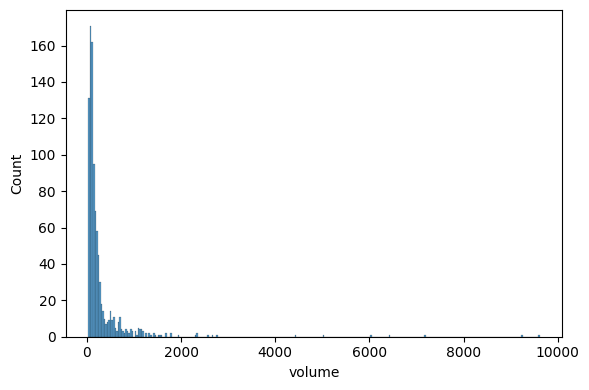

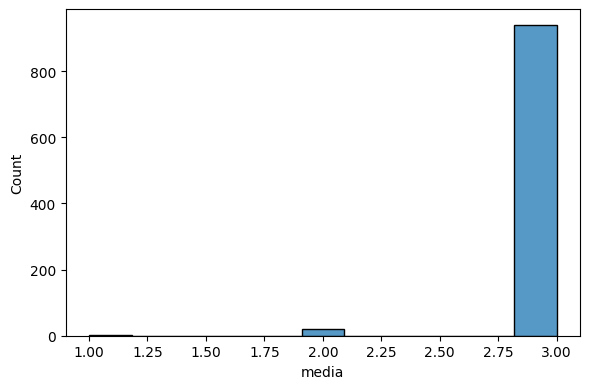

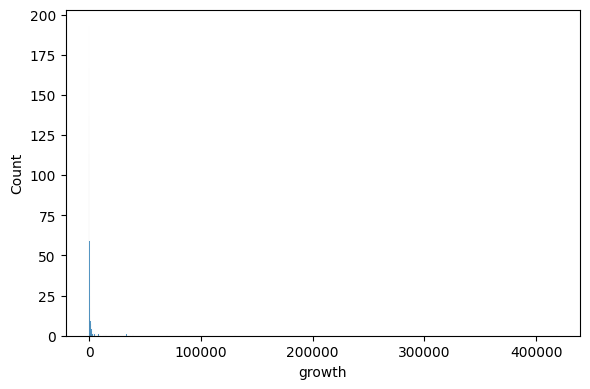

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = ["volume", "media", "growth"]

for col in target_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_unique, x=col, bins='auto')  # bins='auto' 대신 적당한 정수
    plt.tight_layout()
    plt.show()

In [8]:
# 1. volume: 로그 변환 후 Min-Max 스케일링
df_unique['v_log'] = np.log1p(df_unique['volume'])
v_min = df_unique['v_log'].min()
v_max = df_unique['v_log'].max()
df_unique['v_score'] = (df_unique['v_log'] - v_min) / (v_max - v_min)

# 2. growth: 95분위수 상한선으로 클리핑 후 Min-Max 스케일링
g_cap = df_unique['growth'].quantile(0.95)
df_unique['g_clipped'] = df_unique['growth'].clip(upper=g_cap)
g_min = df_unique['g_clipped'].min()
g_max = df_unique['g_clipped'].max()
df_unique['g_score'] = (df_unique['g_clipped'] - g_min) / (g_max - g_min)

# 3. media: 단순 Min-Max 스케일링
m_min = df_unique['media'].min()
m_max = df_unique['media'].max()
df_unique['m_score'] = (df_unique['media'] - m_min) / (m_max - m_min)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1248861529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['v_log'] = np.log1p(df_unique['volume'])
C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1248861529.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['v_score'] = (df_unique['v_log'] - v_min) / (v_max - v_min)
C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\1248861529.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [10]:
df_unique

,Alert_date,Title,Content,volume,media,growth,v_log,v_score,g_clipped,g_score,m_score
0,202607200605,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1.0,4.820282,0.241606,-1.0,0.007050,1.0
9,202607200705,경기지역 7월 아파트 분양 1만6983세대…비규제지역 반사이익 기대,... 3만1311세대(일반분양)로 파악됐다. 이 가운데 <b>경기도</b>는 1만...,91,3,15.0,4.521789,0.189584,15.0,0.011228,1.0
17,202607200805,"성남시, 11년 만에 홈페이지 전면 개편…AI 검색 도입",<b>정부</b> 통합인증 도입·고령층 웹 접근성 강화 시민 의견 반영해 ... 서...,206,3,6.0,5.332719,0.330915,6.0,0.008878,1.0
24,202607200905,"산업부, 반월시화서 <b>AI</b> 제조혁신…2028년까지 280억원 투입",... 국가산업단지를 인공지능(<b>AI</b>) 기반 제조혁신의 핵심 ... 밀집...,196,3,19.0,5.283204,0.322286,19.0,0.012272,1.0
33,202607200905,"경기 행정서비스를 한곳에서 ‘경기융합타운’, 조성 15년 만에 완료","... <b>경기도</b>청·도의회, <b>경기도</b>교육청, 한국은행 경기본부,...",46,3,327.0,3.850148,0.072529,327.0,0.092694,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7180,202607291505,"이재준 ""<b>수원</b>을 세계적 관광 브랜드로""…'<b>수원</b> 방문의 해'...",경기 <b>수원</b>시가 ‘2026~2027 <b>수원</b> 방문의 해‘를 앞세...,197,3,79.0,5.288267,0.323168,79.0,0.027939,1.0
7189,202607291505,“7세 남아가 5·6세 두딸 성추행” 학원 CCTV에 충격…남아 부모는 “여아도 동...,<b>경기도</b>의 한 줄넘기학원에서 6세 딸이 7세 남아에게 성추행을 당했다고 ...,69,3,99.0,4.248495,0.141954,99.0,0.033161,1.0
7198,202607291505,"목포시 ""서부권 메디컬타운 구상 환영""…의대·대학병원 조성 촉구","... /목포시 목포시와 지역 정치권, 각급 기관이 전남광주<b>통합</b>특별...",64,3,149.0,4.174387,0.129039,149.0,0.046217,1.0
7207,202607291505,"안민석 경기교육감 ""운동하는 학생, 공부하는 선수 만든다""","... 전문가 특강을 열고, ‘<b>경기도</b>형 학교 스포츠 혁신 정책’의 .....",63,3,120.0,4.158883,0.126336,120.0,0.038644,1.0


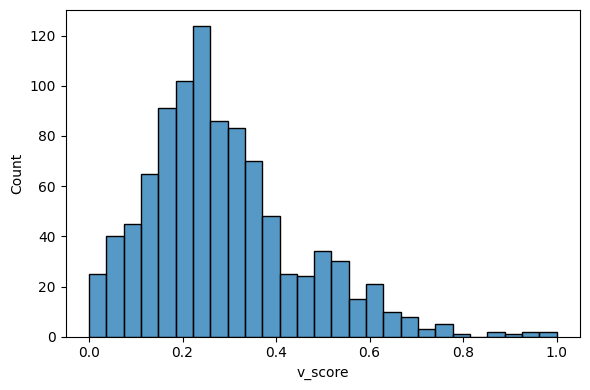

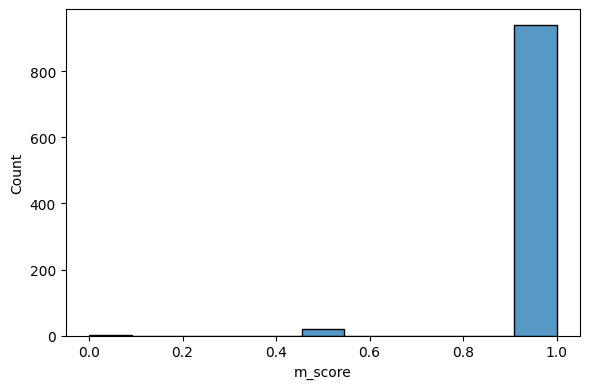

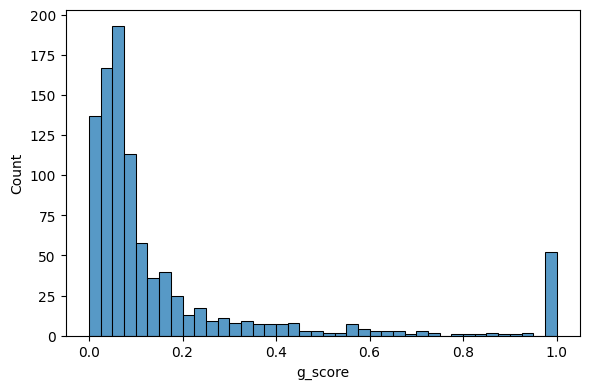

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = ["v_score", "m_score", "g_score"]

for col in target_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_unique, x=col, bins='auto')  # bins='auto' 대신 적당한 정수
    plt.tight_layout()
    plt.show()

In [13]:
df_unique

,Alert_date,Title,Content,volume,media,growth,v_log,v_score,g_clipped,g_score,m_score
0,202607200605,"[삶] ""탱크의 무한궤도 파편이 대통령 관람석까지 날아들었다""",... 있듯이 연구소이지만 <b>정부</b> 기관의 성격이 강하다 ... 장병들 ...,123,3,-1.0,4.820282,0.241606,-1.0,0.007050,1.0
9,202607200705,경기지역 7월 아파트 분양 1만6983세대…비규제지역 반사이익 기대,... 3만1311세대(일반분양)로 파악됐다. 이 가운데 <b>경기도</b>는 1만...,91,3,15.0,4.521789,0.189584,15.0,0.011228,1.0
17,202607200805,"성남시, 11년 만에 홈페이지 전면 개편…AI 검색 도입",<b>정부</b> 통합인증 도입·고령층 웹 접근성 강화 시민 의견 반영해 ... 서...,206,3,6.0,5.332719,0.330915,6.0,0.008878,1.0
24,202607200905,"산업부, 반월시화서 <b>AI</b> 제조혁신…2028년까지 280억원 투입",... 국가산업단지를 인공지능(<b>AI</b>) 기반 제조혁신의 핵심 ... 밀집...,196,3,19.0,5.283204,0.322286,19.0,0.012272,1.0
33,202607200905,"경기 행정서비스를 한곳에서 ‘경기융합타운’, 조성 15년 만에 완료","... <b>경기도</b>청·도의회, <b>경기도</b>교육청, 한국은행 경기본부,...",46,3,327.0,3.850148,0.072529,327.0,0.092694,1.0
...,...,...,...,...,...,...,...,...,...,...,...
7180,202607291505,"이재준 ""<b>수원</b>을 세계적 관광 브랜드로""…'<b>수원</b> 방문의 해'...",경기 <b>수원</b>시가 ‘2026~2027 <b>수원</b> 방문의 해‘를 앞세...,197,3,79.0,5.288267,0.323168,79.0,0.027939,1.0
7189,202607291505,“7세 남아가 5·6세 두딸 성추행” 학원 CCTV에 충격…남아 부모는 “여아도 동...,<b>경기도</b>의 한 줄넘기학원에서 6세 딸이 7세 남아에게 성추행을 당했다고 ...,69,3,99.0,4.248495,0.141954,99.0,0.033161,1.0
7198,202607291505,"목포시 ""서부권 메디컬타운 구상 환영""…의대·대학병원 조성 촉구","... /목포시 목포시와 지역 정치권, 각급 기관이 전남광주<b>통합</b>특별...",64,3,149.0,4.174387,0.129039,149.0,0.046217,1.0
7207,202607291505,"안민석 경기교육감 ""운동하는 학생, 공부하는 선수 만든다""","... 전문가 특강을 열고, ‘<b>경기도</b>형 학교 스포츠 혁신 정책’의 .....",63,3,120.0,4.158883,0.126336,120.0,0.038644,1.0


In [14]:
raw_df['volume']=raw_df['volume'].str.replace(',','')
raw_df['growth']=raw_df['growth'].str.replace(',','')
raw_df['volume']=raw_df['volume'].astype(int)
raw_df['growth']=raw_df['growth'].astype(float)

In [15]:
mapping_df=df_unique[['volume','growth','media','v_score','g_score','m_score']]
df=raw_df.merge(mapping_df, on=['volume','growth','media'], how='left')

In [16]:
df['Alert_date']=pd.to_datetime(df['Alert_date'], format='%Y%m%d%H%M')
df['day']=df['Alert_date'].dt.day
df['hour']=df['Alert_date'].dt.hour
df=df.drop(['volume','media','growth', 'Alert_date'], axis=1)



In [17]:
days=[i for i in range(20,30)]
hour_dict={'dawn':[0,1,2,3,4,5],
           'b_n':[6,7,8,9,10,11],
           'a_n':[12,13,14,15,16,17],
           'night':[18,19,20,21,22,23]}

In [18]:
df_labeled=df.copy()

In [19]:
df_labeled['scoring']=0.2*df_labeled['v_score']+0.4*df_labeled['g_score']+0.4*df_labeled['m_score']

In [20]:
df_labeled['is_0.4score'] = (df_labeled['scoring'] >= 0.4).astype(int)


In [21]:
df_labeled['is_0.5score'] = (df_labeled['scoring'] >= 0.5).astype(int)
df_labeled['is_0.6score'] = (df_labeled['scoring'] >= 0.6).astype(int)
df_labeled['is_0.7score'] = (df_labeled['scoring'] >= 0.7).astype(int)


In [23]:
df_labeled.to_excel('df_labeld.xlsx', header=True)

In [24]:
days=[i for i in range(20,30)]
hour_dict={'dawn':[0,1,2,3,4,5],
           'b_n':[6,7,8,9,10,11],
           'a_n':[12,13,14,15,16,17],
           'night':[18,19,20,21,22,23]}

In [25]:
def get_time_zone(hour):
    if hour in [0, 1, 2, 3, 4, 5]:
        return 'dawn'
    elif hour in [6, 7, 8, 9, 10, 11]:
        return 'b_n'
    elif hour in [12, 13, 14, 15, 16, 17]:
        return 'a_n'
    elif hour in [18, 19, 20, 21, 22, 23]:
        return 'night'
    else:
        return 'unknown'

In [26]:
df_labeled['time_zone'] = df_labeled['hour'].apply(get_time_zone)

In [27]:
sampled_df = df_labeled.groupby(['day', 'time_zone']).apply(lambda x: x.sample(n=5, replace=True)).reset_index(drop=True)

C:\Users\이진섭\AppData\Local\Temp\ipykernel_40684\4294375751.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_labeled.groupby(['day', 'time_zone']).apply(lambda x: x.sample(n=5, replace=True)).reset_index(drop=True)


In [28]:
len(raw_df)

7225

In [29]:
sampled_df

,Title,Content,v_score,g_score,m_score,day,hour,scoring,is_0.4score,is_0.5score,is_0.6score,is_0.7score,time_zone
0,"전국상의, '그냥드림' 공동챌린지…복지 사각지대 해소 나선다 새 창 열림",... 신기업가정신협의회(ERT)는 20일 경기 <b>화성시</b>나래울종합사회복지...,0.229983,0.124027,1.0,20,12,0.495608,1,0,0,0,a_n
1,"추미애, ""<b>경기도</b>형 좌석예약버스 '경기편하G버스', 2030년까지 18...",... 개 노선 가운데 2개 노선은 <b>경기도</b>와 서울시를 잇는 시도간 노선...,0.486347,0.103922,1.0,20,17,0.538838,1,1,0,0,a_n
2,"GC녹십자의료재단, ISO 45001 인증 새 창 열림",... 6일 <b>경기도</b> 용인 GC녹십자의료재단 진단검사센터에서 ... 대표...,0.516678,0.053005,1.0,20,17,0.524538,1,1,0,0,a_n
3,"최민 <b>경기도</b>의원, 경제노동위 부위원장 선임…""민생경제 부양 역군 될 것""",[<b>수원</b>=뉴스핌] 국회 보좌진 출신의 재선 도의원인 최민 의원(더불어민주...,0.263998,0.067366,1.0,20,16,0.479746,1,0,0,0,a_n
4,"<b>경기도</b>교육청, 안민석표 'RAS 경기 예술교육' 본격 시동 새 창 열림",<b>경기도</b>교육청이 'RAS 경기 문예체 교육' 안착을 위해 본격 시동을 걸...,0.305586,0.076766,1.0,20,12,0.491824,1,0,0,0,a_n
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,'아니 왜' 90억 안경 에이스는 왜 '패패패패패패패패패' 대전만...,... 2사 만루 위기를 자초했다. 김태형 롯데 <b>감독</b>이 직접 마운드에 ...,0.634557,0.149616,1.0,29,0,0.586758,1,1,0,0,dawn
171,"홍명보, 2년간 자택 주변에서 법카 1,400만 원 사용",... 전 축구대표팀 <b>감독</b>이 대한축구협회 법인카드를 사용해 자택 인근 ...,0.634557,0.149616,1.0,29,0,0.586758,1,1,0,0,dawn
172,'아니 왜' 90억 안경 에이스는 왜 '패패패패패패패패패' 대전만 오면 작아지나…3...,... 2사 만루 위기를 자초했다. 김태형 롯데 <b>감독</b>이 직접 마운드에 ...,0.634557,0.149616,1.0,29,0,0.586758,1,1,0,0,dawn
173,"홍명보, 자택 인근서 법카 1400만원 사용…호텔·정육점 등 결제",... 전 축구 국가대표팀 <b>감독</b>. /뉴스1 홍명보 전 축구 국가대표팀 ...,0.634557,0.149616,1.0,29,0,0.586758,1,1,0,0,dawn


In [30]:
sampled_df=sampled_df.drop(['v_score','g_score','m_score','day','hour'], axis=1)

In [31]:
sampled_df.drop('time_zone', axis=1, inplace=True)

In [32]:
sampled_df.to_excel('sample_df.xlsx', header=True)